# CAB420, Dimension Reduction, Example 6: PCA and Clustering
Dr Simon Denman (s.denman@qut.edu.au)

## Overview

This example will have a brief look at how we could combine PCA and clustering. As both are unsupervised methods, using these together can be a good option. With PCA we can create a simplified dataset, hopefully removing some information that's not very important (or might even be noise and other useless junk). We can then throw the reduced data into a clustering approach, from which we could continue our data exploration.  

We'll apply this to the problem of basketball analytics. As a bit of preamble for this, basketball traditionally considered that there are five positions (centre, power forward, small forward, shooting guard, and point guard), but the game has evolved and is increasingly played in a "positionless" way. Various analyses have suggested that these positions no longer do a great job capturing play styles, and other breakdowns of positions have been suggested. It's not so much that defined roles (or positions) no longer exist, just that those original five often don't best capture the different player roles and styles. Here, we'll have a very rough look at how we could start that process of finding player roles ourselves.

As always, there are a few massive caveats with what follows:
* Ideally, we'd use more advanced metrics in our analysis that capture things like offensive and defensive production, and somewhat quantify the impact of the individual towards overall team performance. If you don't know what I mean by advanced metrics don't worry, it's a sports thing and they're basically just fancy stats that go beyond counting things;
* If we're serious, we'd consider using data from more than one season;
* We could look at play-by-play data as well to get a richer picture again.

That said, the below will give an idea of how we can use dimension reduction and clustering in combination to start to understand and identify patterns in the data.

### Why not LDA?

LDA is supervised. Clusterig is unsupervised. For this reason, you won't see too many places where you first apply LDA, making use of all the wonderful labels you have, and then go and ignore those and use clustering. The one exception to this would be in the biometric space, where you may learn a subspace using a dimension reduction method, and then model that subspace using a GMM. This is a fairly successful biometrics approach that was very common before the dawn of deep learning. 

## Too Long; Didn't Read
The main take home points from this example are:
* PCA can be used as pre-processing prior to applying clustering. As both methods are unsupervised, they naturally fit well together. The fact that both methods are moderatley interpretable means they work well for knowledge discovery tasks.
* The usual rules around PCA and clustering hyper-parameters apply. You can use the the explained variance to guide the number of PCs you keep, and you can use a whole heap of methods to select K for K-means of a GMM. That said, you can also make your own decisions based on other information that's either in the data, or that you may posess about the problem/data.
* In practice, when using these methods in combination for knowledge discovery you'd expect to go through a few iterations, trying different hyper-parameters, analysing results, and seeing if things make sense. For the sake of keeping this from being too long we've avoided that, but in a real application this is what you'd want to do.

In [1]:
import numpy
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import sklearn
import matplotlib.pyplot as plt
import pandas
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import seaborn

## The Data

We're using data from the 2023-2024 NBA season which I found on [Kaggle](https://www.kaggle.com/datasets/vivovinco/2023-2024-nba-player-stats). Our data consists of season averages for all players, covering the common game statistics (points, rebounds, assists, blocks, fouls, shooting attempts and percentages, etc). We don't have any of the advanced metrics, and we're not looking at play-by-play data, so if you're thinking this is going to be some hardcore exploration of sports analytics, it's not.

With that out the way, there are a few bits of pre-processing we need to do with the data:
* Remove duplicate rows. Where a player has been traded during the season, they will have multiple rows in the data table. The first row will be their overall stats for the whole season, and they'll have row with the stats for each team that they've played with that year. We'll just take the first row for each player (i.e. their overall stats for the season).
* Remove rows for players with too few games. I've picked 20 here, but this is quite an arbitrary choice. Really, we just want to get rid of players who've played too little and whose game stats are thus, possibly, a bit iffy.
* Normalise some columns. A typical step for us with any data anlaysis is standardisation. We're not going to do that yet. Instead, we're going to normalise our data columns into per 36 min data. What I mean by that is we'll use the "minutes per game" value to scale a bunch of other data, to compensate for playing time and allow us to better capture playing style, rather than just simply who's on the court the most.
* Select some columns to use. In our case, we're going to take colums for
  * all things shooting and scoring (2 point, 3 point and free throw makes, attempts and percentage, and points scored)
  * offensive and defensive rebounds
  * assists
  * steals
  * blocks
  * turnovers
  * fouls    
* Standardise the data. Why am I standardising after doing my other normalisation? Aren't these the same thing? Here they're actually doing very different things. Our first normalisation step was designed to account for player's playing different amounts of time, and we scaled stats for each player to see what might have happened if all players played for 36 minutes a game (there's a heap of things this doesn't consider of course, like who else you're sharing the court with which greatly impacts production). However, after this we still have scale variation across columns. Values for columns like points and rebounds will be much higher than for steals and blocks. Shooting percentages will be in the range [0..1]. To compensate for this, we need to standardise.

Note that with my data processing I am removing some redundancy here. For example rather than include offensive, defensive and total rebounds, I'm just going to take the individual offensive and defensive values as these are simply summed to get the total number. Likewise I'm not considering the total field goal makes, attempts and percentages as this is just combining the 2 and 3 point values. Note that if I wanted, I could leave this stuff in the data and let PCA do that redundancy removal for me, however removing it now will make some later visualisation a bit easier to follow, which for a teaching example is a good thing.

In [2]:
# load the data. Note that the data is using ; as the column delimiter
data = pandas.read_csv('../data/nba/2023-2024 NBA Player Stats - Regular.csv', delimiter=';')
# drop duplicate rows for players, keeping just the first row
data = data.drop_duplicates(subset='Rk', keep="first")
# drop players with too few games
data = data.drop(data[data.G < 20].index)
# get the time scaling factor
time_factor = data['MP'] / 36.0
# select some columns to normalise. These are the "count" type bits of data where we'd expect more court time to lead to bigger numbers
cols_to_norm = ['FG', 'FGA', '3P', '3PA', '2P', '2PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']
# normalise the columns we've identified
for c in cols_to_norm:
    data[c] = data[c] / time_factor

# select some columns to use in our analysis
cols_to_use = ['3P', '3PA', '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 
               'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

# pull out the position as a categorical - we're just using this for display
data['Pos'] = data.Pos.astype('category')
# pull out the data
data_to_use = data[cols_to_use].to_numpy()

# standardise the data
scaler = StandardScaler().fit(data_to_use)
data_to_use = scaler.transform(data_to_use)

### A Quick Visualisation

Before we start on PCA and clustering, let's quickly visualise why this might be a good idea. If the traditional positions within basketball are a good way of grouping players, we'd expect a scatter plot coloured by position to give some nice groupings. 

As we have 17 dimensions, we'll use TSNE to help out here.

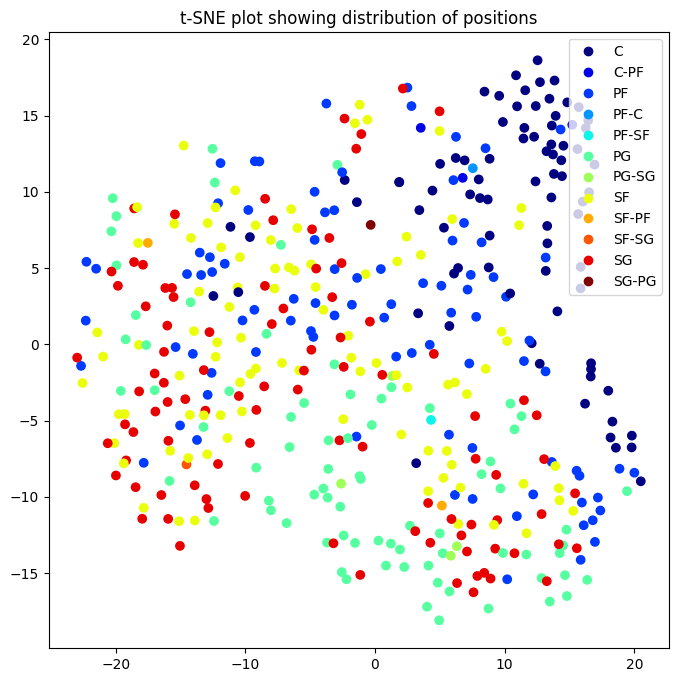

In [3]:
tsne_embeddings = TSNE(random_state=4).fit_transform(data_to_use)
fig = plt.figure(figsize=[8, 8])
ax = fig.add_subplot(1, 1, 1)
scatter = ax.scatter(tsne_embeddings[:,0], tsne_embeddings[:,1], c = data['Pos'].cat.codes, cmap='jet');
ax.legend(handles=scatter.legend_elements()[0], labels=data['Pos'].cat.categories.to_list()) 
ax.set_title('t-SNE plot showing distribution of positions');

What we see if lots of colours everywhere. There are some small local groupings, but overall this looks pretty lose. For those wondering why we have 12 classes when we talked about 5 positions above, there are a number of players that effectivley play multiple of the traditional positions - hence why we have these combo positions. 

### Applying PCA

Let's throw PCA at this now. I'm going to fit the PCA transform, and then visualise the components. 

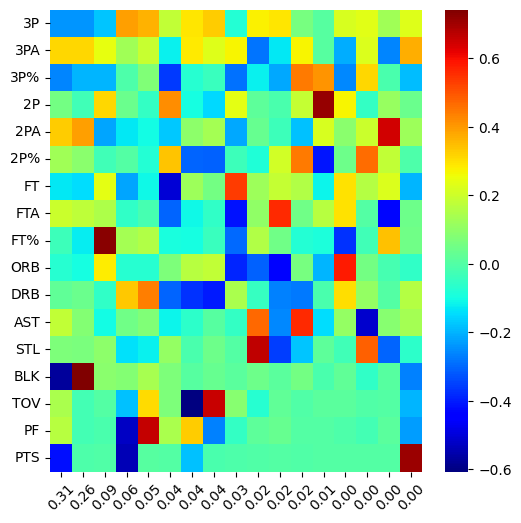

In [4]:
pca = decomposition.PCA()
pca.fit(data_to_use)
fig = plt.figure(figsize=[6, 6])
ax = fig.add_subplot(1, 1, 1)
seaborn.heatmap(pca.components_, ax=ax, yticklabels=cols_to_use, xticklabels=['%1.2f' % d for d in pca.explained_variance_ratio_], cmap='jet')
ax.tick_params(axis='x', rotation=45)

By using the real-world meanings attached to the original inputs, we can try and attach meanings to the principal components that we learn. Looking at the first few PCs:
* PC1 is positivley correlated with two and three point attempts, and negatively correlated with 3 three point shots made and percentage, and with blocks and points. Perhaps this dimension is capturing something in relation to scoring efficiency (trade off between shots and makes) and volume for guards (negative correlation with blocks)?
* PC2 is again positivley correlated with two and three point attempts, but also very strongly with blocks. There is negative correlation with most other shooting metrics. The overall meaning here is again hard to pin down, but perhaps as per PC1 this is considering scoring efficiency for centres and forwards (positive correlation with blocks)?
* PC3 is positively correlated with free throw percentage, offensive rebounds, and two point shots made. There is again negative correlation with most other shooting metrics. This dimensions is perhaps capturing a player's ability/tendancy towards scoring inside.
* PC4 has positive weights for three points makes, and defensive rebounds. Negative correlation is present for free throws, turnovers, fouls and points. Perhaps this dimension is reflective of a 3-and-D role (defensive focussed wing player and three point exponent).
* PC5 has positive weights for fouls, turnovers, defensive rebounds and three pointers made. There are no strong negative correlations. This is (maybe?) another wing-player centric component, though for a wing who has more of a playmaking role (compared to PC increased assists and turnovers).

At this point I'm going to stop trying to read meanings into the PCs (mostly), but hopefully you get the idea here. Keep in mind that do be able to do this, there are a few things to keep in mind:
* You need to be using features where there is a real-world meaning attached. For tabular data like we have that's easy. If I have signal data, either in a raw or transformed (i.e. HOG for example with images) state, then this sort of analysis becomes much harder, if not impossible.
* A degree of domain knowledge is needed to actually make sense of this. My basketball knowledge is not fantastic, hence the use of words like "perhaps" and "maybe" a lot above - I'm somewhat guessing here.
* PCA is learning a new set of dimensions (components), and these won't tie neatly to roles. Thre is not one PC that captured "centre" (probably). Rather they will capture dimensions along which players vary. Consider PC1 from above. Bearing in mind the above point about domain knowledge (and my limitations with respect to that), a player who has a positive score for this dimension could be expected to put up an above average number of shots, but score a below average number of points (i.e. be an inefficent scorer), while a player with a negative score would be the opposite. Hence we can (maybe) see this dimension as capturing something about scoring efficiency.

At this point we can pick some dimensions to retain and proceed. Here we can take a couple of different approaches:
* Based on our analysis of the individual PCs, we might decide that the first N capture identifiable traits that we wish to consider, and hence we might just take that many components.
* We might look for a percentage of explained variance, and proceed in the way that we usually do.

With this, we also need to keep in mind the interaction between PCA and our clustering. If we're going to use something to select a value of K, then keeping more PCs will see us tend towards fewer clusters. Depending on what we want to do, keeping a smaller number of PCs may be preferable. As such, we're going to retain 75% of the variance (feel free to play with this value though).

In [5]:
cumulative_sum = numpy.cumsum(pca.explained_variance_ratio_, axis=0)
thresohld = 0.75
components_to_keep = numpy.where(cumulative_sum >= thresohld)[0][0] + 1
print(components_to_keep)

5


Based on keeping 75% of the variance, we're keeping 5 components. So we'll transform our data and keep just the first five components.

In [6]:
transformed_data = pca.transform(data_to_use)[:, 0:components_to_keep]
print(transformed_data.shape)

(445, 5)


And now, we can throw our data into our clustering. In situations like this example you may already have an idea of how many clusters you want - or at least a ballpark estimate. For example, we could say that we expect at least 5, as there are five positions on the court and we expect at least that many clusters to exist.

In [7]:
# function to compute the approximate BIC
def compute_approximate_bic(kmeans,X):
    
    k = numpy.shape(kmeans.cluster_centers_)[0]*(numpy.shape(kmeans.cluster_centers_)[1] + 1)
    m = len(X)
    
    approx_bic = m*numpy.log(kmeans.inertia_ / m) + k*numpy.log(m)
    return approx_bic    

# function to estimate k for k-means using the approximate BIC, this will search all values of K from [1..max_k], and evaluate each 
# num_itts times with different random seeds. The function will return a list of average approx BICs for all considered K's
def estimate_k_kmeans(max_k, num_itts, data):
    bic = []
    for i in range (max_k):
        b = 0
        for j in range(num_itts):
            kmeans = KMeans(n_clusters=i+1, random_state=j, n_init='auto').fit(data)
            b += compute_approximate_bic(kmeans, data)
        bic.append(b/num_itts)

    return bic

# function to estimate k for a GMM using the BIC, this will search all values of K from [1..max_k], and evaluate each 
# num_itts times with different random seeds. The function will return a list of average BICs for all considered K's
def estimate_k_gmm(max_k, num_itts, data):

    bic = []
    for i in range (max_k):
        b = 0
        for j in range(num_itts):
            gmm = GaussianMixture(i+1, random_state=j).fit(data)
            b += gmm.bic(data)          
        bic.append(b/num_itts)

    return bic

# evaluate some K's for K-means
bic_kmeans = estimate_k_kmeans(50, 10, transformed_data)
# evaluate some K's for a GMM
bic_gmm = estimate_k_gmm(50, 10, transformed_data)

# get best K's
k_kmeans = numpy.argmin(bic_kmeans) + 1
k_gmm = numpy.argmin(bic_gmm) + 1
print(k_kmeans)
print(k_gmm)

6
2


Assuming you've changed nothing above, you'd be seeing 6 clusters with K-means, and 2 with a GMM. Remember that K-means has way fewer parameters than a GMM, hence we see a measure like BIC which trades-off goodness of fit with complexity arrive at more clusters. If we changed the covariance type of the GMM to being something simpler, we may see more clusters being chosen for a GMM.

For our task, if we're using K-means we'd probably continue with 6 clusters, at least for a first pass. If we're using a GMM, we'd probably pick a different value of K, either by using a different metric or by just taking our own best guess. This is also one situation where you may well have prior knowledge of how many roles to expect, and if you did, then you'd be free to use that too.

In [8]:
kmeans = KMeans(n_clusters=k_kmeans, random_state=4).fit(transformed_data)

Using 6 clusters, we get the following split across the data. 

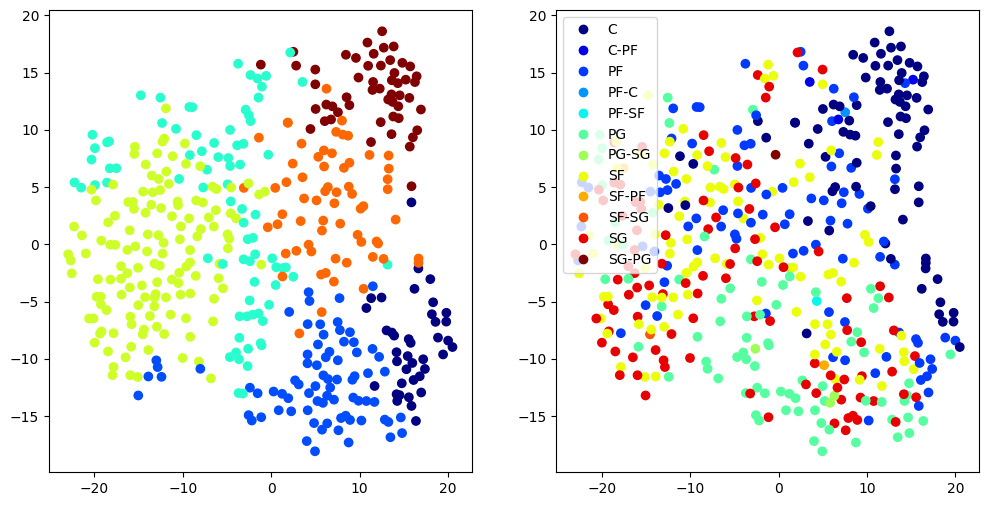

In [9]:
fig = plt.figure(figsize=[12, 6])
ax = fig.add_subplot(1, 2, 1)
scatter = ax.scatter(tsne_embeddings[:,0], tsne_embeddings[:,1], c = kmeans.labels_, cmap='jet');
ax = fig.add_subplot(1, 2, 2)
scatter = ax.scatter(tsne_embeddings[:,0], tsne_embeddings[:,1], c = data['Pos'].cat.codes, cmap='jet');
ax.legend(handles=scatter.legend_elements()[0], labels=data['Pos'].cat.categories.to_list()) 

Comparing our clustered data to the position information, we see that with the possible exception of the maroon cluster in the top right corner corresponds to a subset of the centres (and maybe some power fowards), our clustering really isn't driven along positional lines. Given that the position groups tend to overlap heavily, that's perhaps not much of a surprise. 

This plot alone doesn't tell us too much about how good (or bad) our clusters are - we'll need to dig more into the data for that info. The following plots attempt this. We'll look at box plots that compare each cluster. We'll plot these for the standardised values, which will help us see how the clusters differs from the aveage NBA player, and the real values that we'll get by using the `inverse_transform` function in the standard scaler. This second set of numbers will help provide a bit more context as that will give us actual points, rebounds, etc, rather than the standardised values.

Text(0.5, 1.0, 'Box Plot for Clusters with Absolute Values')

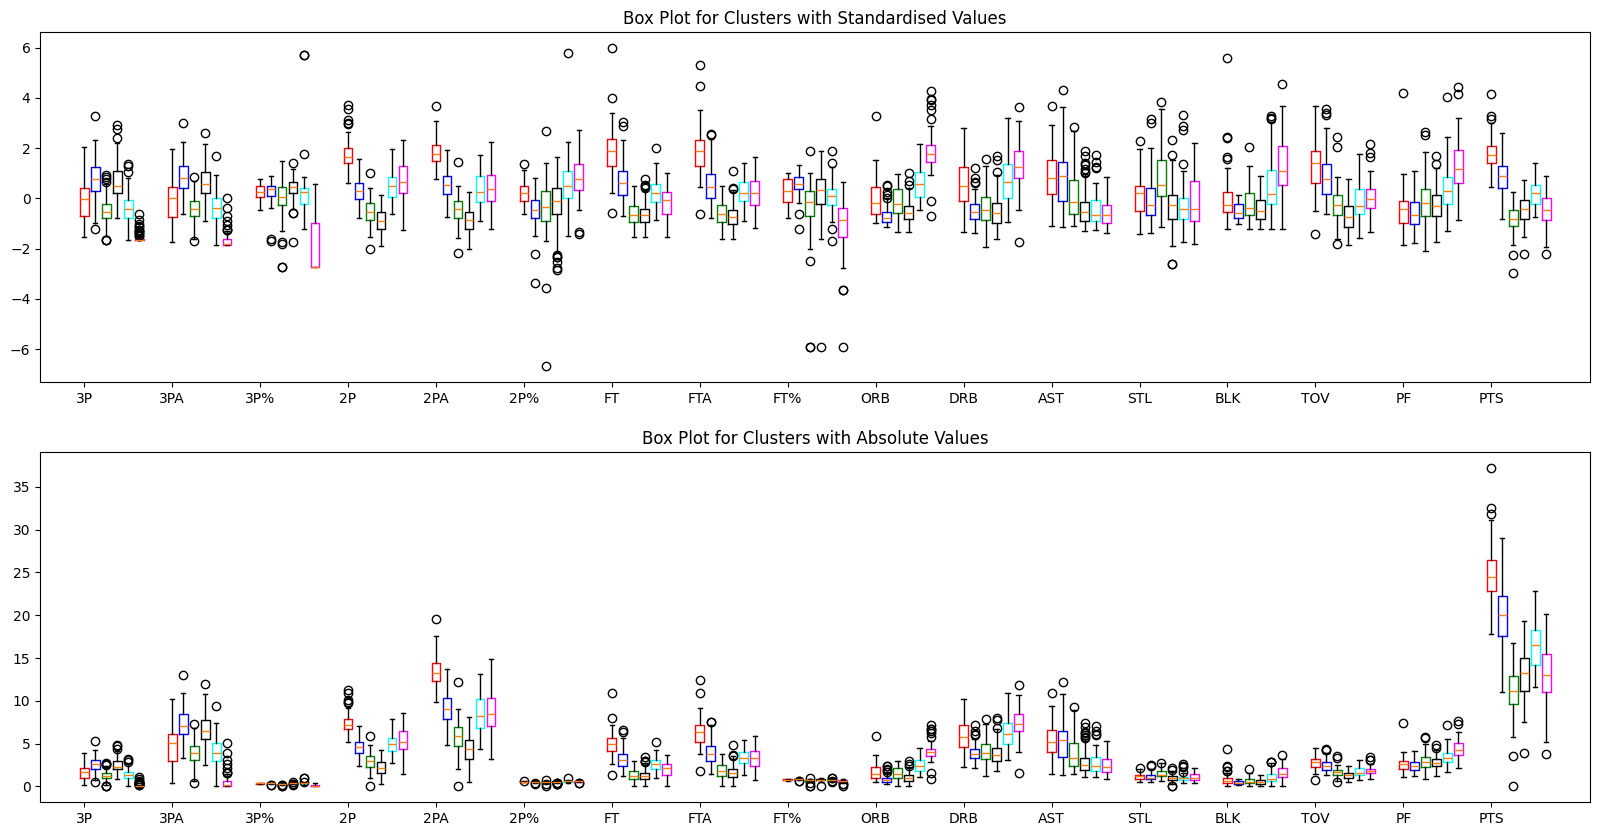

In [10]:
colours = ['red', 'blue', 'green', 'black', 'cyan', 'magenta']

fig = plt.figure(figsize=[20, 10])
ax = fig.add_subplot(2, 1, 1)
for i in range(k_kmeans):
    pos = numpy.linspace(0 + i/8, 16 + i/8, 17)
    ax.boxplot(data_to_use[kmeans.labels_ == i, :], positions=pos, widths=0.1, boxprops=dict(color=colours[i]))
ax.set_xticks(numpy.linspace(0, 16, 17))
ax.set_xticklabels(cols_to_use)
ax.set_title('Box Plot for Clusters with Standardised Values')

ax = fig.add_subplot(2, 1, 2)
for i in range(k_kmeans):
    pos = numpy.linspace(0 + i/8, 16 + i/8, 17)
    ax.boxplot(scaler.inverse_transform(data_to_use[kmeans.labels_ == i, :]), positions=pos, widths=0.1, boxprops=dict(color=colours[i]))
ax.set_xticks(numpy.linspace(0, 16, 17))
ax.set_xticklabels(cols_to_use)
ax.set_title('Box Plot for Clusters with Absolute Values')

Looking at the above, we might characterise our 6-clusters as follows:
* Cluster 0: Strong (possibly primary) scorer, scoring many more points than average. Takes a lot of 2-point shots and get's a lot of free throws. Also has a solid playmaking role, with more assists and turnovers than average.
* Cluster 1: Similar to 1, though more focussed on 3-point shooting and typically not quite as high scoring (though still well above average). Perhaps a stronger playmaker (similar assists, fewer turnovers).
* Cluster 2: Below average in shooting and scoring, perhaps more defensive minded with high numbers of steals.
* Cluster 3: Slightly above average 3 point shooter, and average in most other ways.
* Cluster 4: Above average interior scorer and (maybe) a passable three point shooter, and a bit above average in terms of blocks and rebounds. Maybe capturing more mobile bigs.
* Cluster 5: Cannot score from outside, though strong interior scorer and above average rebounder and shot blocker. Likely a cluster of old-style bigs.

As always, the above is somewhat subjective and you may see something else in the data, but you can hopefully see how such an analysis could play out.

The other thing we could do at this point to validate our clustering would be to pull out the names of players in clusters and see if this actually makes sense. For the sake of keeping this from getting too long, but this would be a good thing to do. If you wanted to do this, you could do something like this: `data[kmeans.labels_ == 0]` (I'd argue while the grouping in cluster 0 is far from perfect, it's not bad all the same).

## Final Thoughts

So, what have we learned today?

Clustering and PCA can be combined in a quite a sensible way for knowledge discovery type tasks. The fact that both are unsupervised methods means they do work well together. We can use PCA to first simplify our dataset, which can make our subsequent clustering a bit easier.

One concern you may have with what we've done is the loss of information via PCA. We've only kept 75% of the variance, surely this is bad? Well, it depends. We don't have that much data, and we want to identify the primary groups (i.e. clusters) in the data. Keeping details that are unimportant (i.e. explain little variance) will not help us pull out the major groups in the data. Keeping these in will just make our clustering more sensitive to noise, so the data reduction here is not necessarily a bad thing. 

That said, if we we're doing this in anger there are a number of other things that you would look at and consider, including:
* Our data pre-processing and what data is kept/removed. We've removed duplicate rows for players, just taking the overall row for each player. The assumption here is that a players role is not changing when the change teams, adn while this probably holds in most cases, it almost certainly doesn't hold for all. Similarly, we've removed players who played fewer than 20 games. Is 20 the right number? Should we instead have removed players based on the average number of minutes played? Both good questions that should be looked at.
* Did we normalise the data in the most appropraite way? Would standardising the raw stats rather than converting to per 36 minute numbers have been better? Should we have tracked down more advanced metrics to better capture player impact? The answer to that latter question is almost certianly yes (but the dataset didn't contain those). The answer to the first question is a bit murkier, and would require further analysis (and the answer may well change if you have advanced stats in the mix).
* Did we select the correct dimensions? Both in terms of what we pulled from the raw data, and what we took from PCA. Ideally, we'd try a few different options here, and see how including other terms impacts our analysis. For a teaching example this is not really practical (you don't want a notebook that long), but if this was you're job, you'd be evaluating all of those choices.
* Should we be using a GMM? I've used K-means because it's simple, but I'd argue it's a poor choice here for a serious analysis. The spherical clusters are a big limitation and I'd argue this limits our ability to group players, particularly those that don't fit nicely in one box. A GMM would also allow us to identify those players that straddle multiple roles, which would be value when using a small number of clusters.
* Speaking of the number of clusters, have we got this right? We certainly could (and again, if this was your job, should) consider other numbers of clusters. A more fine-grained division may make sense if the aim is to capture subtle differences in style. If the brief is just a broad classification, then perhaps 6 is fine - though you'd probably still at least have a look at options around that and see what happens.

Finally, where would you go from here? Once you've grouped players, then what? There's a few possibilities. You might want to use such a model to help identify like-for-like replacements, or to have a look at line-up composition for example. All of that of course is beyond the scope of this example. 